# How good is the final model, where does it fail, and which targets are met?

This notebook reads the cached XGBoost predictions
(`data/processed/experiments/modelling_xgboost.parquet`) and the
`reports/results/07_*.csv` outputs of the evaluation experiments. It never
refits and never touches the lockbox files.

**Main findings:**
- Pooled macro F1 is 0.717 against a 0.80 target, and the weakest class
  (turbine degradation, TD) is recalled only 19% of the time against 0.70.
  The false alarm rate (12.2%) is more than double its 5% target.
- Confidence is not trustworthy: pooled expected calibration error is 0.176
  against 0.05. Temperature scaling, fitted inside the training folds, made
  ECE worse in three of four folds, so it does not fix this. Class
  predictions are unchanged by it.
- Errors concentrate in a few runs (AF at 75% and 85% load are about 20%
  correct). Removing the day-dependent channels does not give a cleaner
  model: macro F1 falls in three of four folds, so part of the headline
  score leans on channels that identify the day, not the fault.
- The lockbox (unseen severity) labels every row as INJ, so the 90% target
  is met, but the model predicted only INJ there, so this is weak evidence.
- Of the brief's targets, only the unseen-severity target is met; the final
  table below lists each one.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from keyframe import calibration, evaluate, experiments, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)

predictions = experiments.load_modelling("xgboost")
classes = evaluate.CLASS_ORDER
proba = predictions[[f"proba_{c}" for c in classes]].to_numpy()

/home/user/KeyFrame/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Final scores: pooled and per fold

In [2]:
scores = evaluate.summarise(predictions)
scores

,fold,macro_f1,accuracy,false_alarm_rate,worst_recall,worst_recall_class
0,pooled,0.717487,0.761268,0.122309,0.194494,TD
1,40,0.546666,0.709470,0.098993,0.000000,TD
2,60,0.860488,0.878279,0.076194,0.571322,TD
3,75,0.700630,0.675484,0.252734,0.336338,AF
4,85,0.608770,0.730807,0.096783,0.000000,AF


In [3]:
folds = scores[scores["fold"] != "pooled"]
pd.Series(
    {"macro_f1_mean": folds["macro_f1"].mean(), "macro_f1_std": folds["macro_f1"].std()},
)

macro_f1_mean    0.679138
macro_f1_std     0.136443
dtype: float64

## Per-class recall and precision (pooled)

CW is trained on two runs and TD on three, and the 75% load bin has no CW
or TD, so their scores rest on very little data (flagged in the table).

In [4]:
from sklearn.metrics import precision_score, recall_score

recall = recall_score(predictions["y_true"], predictions["y_pred"], labels=classes, average=None)
precision = precision_score(
    predictions["y_true"], predictions["y_pred"], labels=classes, average=None, zero_division=0
)
per_class = pd.DataFrame({"recall": recall, "precision": precision}, index=classes)
per_class["thin_coverage"] = [c in ("CW", "TD") for c in per_class.index]
per_class

,recall,precision,thin_coverage
Normal,0.877691,0.763375,False
AC,0.756286,0.722356,False
AF,0.428353,0.589357,False
INJ,0.995071,1.000000,False
CW,0.978526,1.000000,True
TD,0.194494,0.423889,True


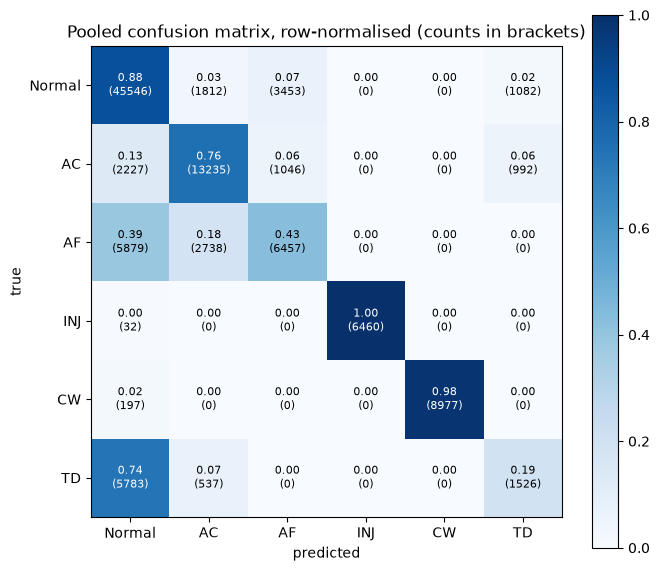

In [5]:
confusion = evaluate.confusion(predictions["y_true"], predictions["y_pred"])
normalised = confusion.div(confusion.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(normalised.to_numpy(), cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(classes)), classes)
ax.set_yticks(range(len(classes)), classes)
for i in range(len(classes)):
    for j in range(len(classes)):
        colour = "white" if normalised.iat[i, j] > 0.5 else "black"
        ax.text(
            j,
            i,
            f"{normalised.iat[i, j]:.2f}\n({confusion.iat[i, j]})",
            ha="center",
            va="center",
            fontsize=8,
            color=colour,
        )
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Pooled confusion matrix, row-normalised (counts in brackets)")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(paths.FIGURES / "07_confusion.png", dpi=150)
plt.show()

## Does the score hold at every load?

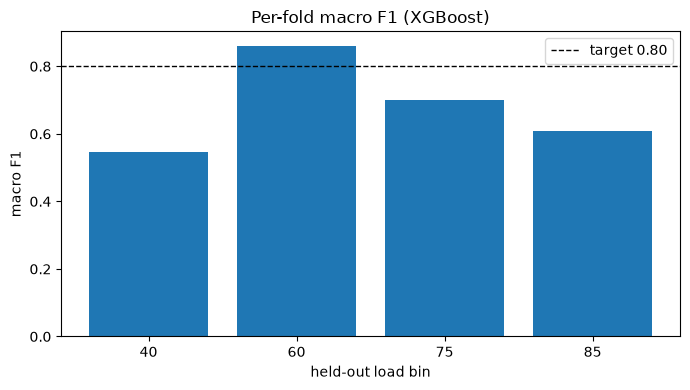

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(folds["fold"].astype(str), folds["macro_f1"], color="tab:blue")
ax.axhline(0.80, color="black", linestyle="--", linewidth=1, label="target 0.80")
ax.set_xlabel("held-out load bin")
ax.set_ylabel("macro F1")
ax.set_title("Per-fold macro F1 (XGBoost)")
ax.legend()
fig.tight_layout()
fig.savefig(paths.FIGURES / "07_fold_scores.png", dpi=150)
plt.show()

## Can the model's confidence be trusted?

In [7]:
calib = pd.read_csv(paths.RESULTS / "07_calibration.csv")
calib[["fold", "pooled_ece_before", "recalibrated", "temperature", "ece_before", "ece_after"]]

,fold,pooled_ece_before,recalibrated,temperature,ece_before,ece_after
0,40,0.1757,True,2.317908,0.089188,0.146587
1,60,0.1757,True,0.492528,0.047275,0.052749
2,75,0.1757,True,1.882138,0.145381,0.158939
3,85,0.1757,True,0.492528,0.499025,0.418083


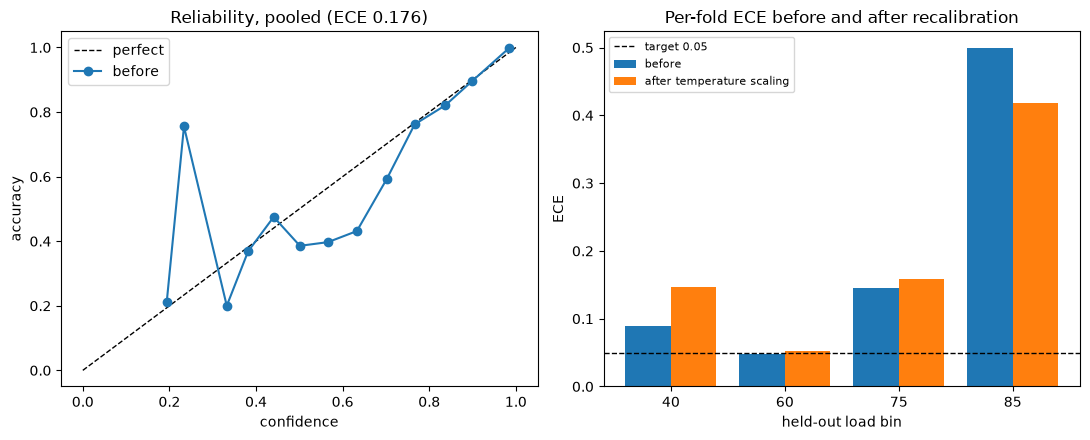

In [8]:
curve = calibration.reliability_curve(predictions["y_true"], proba, classes)
pooled_ece = calibration.expected_calibration_error(predictions["y_true"], proba, classes)

fig, (ax_curve, ax_ece) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_curve.plot([0, 1], [0, 1], "k--", linewidth=1, label="perfect")
ax_curve.plot(curve["confidence"], curve["accuracy"], marker="o", label="before")
ax_curve.set_xlabel("confidence")
ax_curve.set_ylabel("accuracy")
ax_curve.set_title(f"Reliability, pooled (ECE {pooled_ece:.3f})")
ax_curve.legend()

x = range(len(calib))
ax_ece.bar([i - 0.2 for i in x], calib["ece_before"], width=0.4, label="before")
ax_ece.bar([i + 0.2 for i in x], calib["ece_after"], width=0.4, label="after temperature scaling")
ax_ece.set_xticks(list(x), calib["fold"].astype(str))
ax_ece.axhline(0.05, color="black", linestyle="--", linewidth=1, label="target 0.05")
ax_ece.set_xlabel("held-out load bin")
ax_ece.set_ylabel("ECE")
ax_ece.set_title("Per-fold ECE before and after recalibration")
ax_ece.legend(fontsize=8)
fig.tight_layout()
fig.savefig(paths.FIGURES / "07_reliability.png", dpi=150)
plt.show()

Temperature scaling was tried because pooled ECE exceeded 0.05. It helped
only in fold 85 and made folds 40, 60 and 75 worse, so the reported ECE is
the uncalibrated one. Macro F1 is identical before and after (argmax is
unchanged).

## Which runs does the model get wrong?

In [9]:
runs = pd.read_csv(paths.RESULTS / "07_runs.csv")
runs[
    [
        "run",
        "rows",
        "share_correct",
        "top_wrong_label",
        "recall_first_10_min",
        "recall_after",
        "alarm_delay_s",
    ]
].sort_values("share_correct").to_string(max_rows=20)

'                                       run   rows  share_correct top_wrong_label  recall_first_10_min  recall_after  alarm_delay_s\n6                      AF_Clogging_75_Load   5918       0.201926              AC             0.757895      0.285804            NaN\n7                      AF_Clogging_85_Load   6398       0.252423          Normal             0.000000      0.000000            NaN\n4                      AF_Clogging_40_Load   4820       0.477178          Normal             0.090909      0.271782            NaN\n14             Turbine_Degradation_85_Load   5289       0.503687          Normal             0.000000      0.000000            NaN\n12             Turbine_Degradation_40_Load   6397       0.514147          Normal             0.000000      0.000000            NaN\n13             Turbine_Degradation_60_Load   4905       0.545973          Normal             0.494845      0.584319          394.0\n0                       AC_Fouling_40_Load   4678       0.604318          N

## Does the model lean on day-dependent channels?

In [10]:
sens = pd.read_csv(paths.RESULTS / "07_sensitivity.csv")
sens_f1 = sens[sens["metric"] == "macro_f1"][["fold", "headline", "no_day_channels"]]
sens_f1

,fold,headline,no_day_channels
0,40,0.546666,0.634661
6,60,0.860488,0.725001
13,75,0.700630,0.610506
18,85,0.608770,0.346515


In [11]:
sens[sens["metric"].str.startswith("recall_")].pivot(
    index="fold", columns="metric", values="no_day_channels"
).round(2)

metric,recall_AC,recall_AF,recall_CW,recall_INJ,recall_Normal,recall_TD
fold,,,,,,
40,0.64,0.80,NaN,1.0,0.90,0.00
60,0.95,0.91,0.0,1.0,0.93,0.63
75,0.85,0.03,NaN,1.0,0.71,NaN
85,0.00,0.00,1.0,1.0,0.56,0.00


Without the 40 day-dependent channels macro F1 rises in fold 40 but falls
in folds 60, 75 and 85 (fold 85: 0.609 to 0.347). The headline score
therefore partly rests on channels that encode the day, not the fault.

## What happens on unseen severity (the lockbox)?

The lockbox was evaluated once (`keyframe.lockbox`); it is not re-run here.

In [12]:
lockbox = pd.read_csv(paths.RESULTS / "07_lockbox.csv")
lockbox[["scope", "load_bin", "label", "n_rows", "share"]]

,scope,load_bin,label,n_rows,share
0,all,NaN,INJ,6791,1.0
1,load_bin,40.0,INJ,2286,1.0
2,load_bin,60.0,INJ,2648,1.0
3,load_bin,75.0,INJ,1857,1.0


Every lockbox row was labelled INJ, the class of the lockbox runs, so the
90% and 97% targets are met. The model predicted only INJ there, which
makes this a weak test: it cannot show the model tells INJ from the others.

## Final target table

In [13]:
t4 = pd.read_csv(paths.RESULTS / "04_targets.csv").set_index("metric")
t5 = pd.read_csv(paths.RESULTS / "05_targets.csv").set_index("metric")
pooled_row = scores[scores["fold"] == "pooled"].iloc[0]
lock_share = float(lockbox[lockbox["scope"] == "all"]["share"].iloc[0])
physics_passed = 2  # reports/physics_check.md: 2 of 5 faults pass


def status(met: bool) -> str:
    return "met" if met else "not met"


rows = [
    ("Macro F1, held-out loads", "0.52 raw / 0.60 residuals", 0.80, 0.90, pooled_row["macro_f1"]),
    ("Lowest per-class recall", "0.00 (TD, raw)", 0.70, 0.85, pooled_row["worst_recall"]),
    ("False alarm rate", "29.8% raw / 13.4% residuals", 0.05, 0.02, pooled_row["false_alarm_rate"]),
    (
        "Fault detection AUROC",
        "not measured",
        0.95,
        0.98,
        t5.loc["Fault detection AUROC, held-out loads", "value"],
    ),
    (
        "Detection delay (s, median of detected runs)",
        "not measured",
        600,
        300,
        t4.loc["Detection delay (median of detected runs)", "value"],
    ),
    ("Expected calibration error", "not measured", 0.05, 0.03, pooled_ece),
    ("Unseen severity", "not measured", 0.90, 0.97, lock_share),
    ("Physics check (faults passing, of 5)", "not done", 4, 5, physics_passed),
]
lower_is_better = {
    "False alarm rate",
    "Detection delay (s, median of detected runs)",
    "Expected calibration error",
}
table = pd.DataFrame(rows, columns=["metric", "baseline", "target", "stretch", "achieved"])
table["met"] = [
    status(r.achieved <= r.target if r.metric in lower_is_better else r.achieved >= r.target)
    for r in table.itertuples()
]
table["stretch_met"] = [
    status(r.achieved <= r.stretch if r.metric in lower_is_better else r.achieved >= r.stretch)
    for r in table.itertuples()
]
# Notebook 04 judged the delay target not met because 7 of 13 runs were never
# detected; keep that verdict rather than rewarding the median of the detected ones.
delay_row = table["metric"].str.startswith("Detection delay")
table.loc[delay_row, "met"] = status(
    bool(t4.loc["Detection delay (median of detected runs)", "met"])
)
table.loc[delay_row, "stretch_met"] = "not met"
table.loc[len(table)] = [
    "Demo response time (ms)",
    "not built",
    300,
    100,
    float("nan"),
    "measured in roadmap item 11",
    "measured in roadmap item 11",
]
table

,metric,baseline,target,stretch,achieved,met,stretch_met
0,"Macro F1, held-out loads",0.52 raw / 0.60 residuals,0.80,0.90,0.717487,not met,not met
1,Lowest per-class recall,"0.00 (TD, raw)",0.70,0.85,0.194494,not met,not met
2,False alarm rate,29.8% raw / 13.4% residuals,0.05,0.02,0.122309,not met,not met
3,Fault detection AUROC,not measured,0.95,0.98,0.528346,not met,not met
4,"Detection delay (s, median of detected runs)",not measured,600.00,300.00,563.000000,not met,not met
5,Expected calibration error,not measured,0.05,0.03,0.175700,not met,not met
6,Unseen severity,not measured,0.90,0.97,1.000000,met,met
7,"Physics check (faults passing, of 5)",not done,4.00,5.00,2.000000,not met,not met
8,Demo response time (ms),not built,300.00,100.00,NaN,measured in roadmap item 11,measured in roadmap item 11


Spread across folds where it exists: macro F1 per fold ranges from 0.55 to
0.86 (see the fold table above). Detection delay uses only the runs the
alarm ever detected, so it flatters the model; the run table shows how many
runs were never detected.